<a href="https://colab.research.google.com/github/DEEPSEN1998/DEEPSEN1998/blob/main/Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Can we use Bagging for regression problems?

Yes, Bagging can be used for regression problems. The BaggingRegressor in scikit-learn averages the predictions from multiple base regressors trained on different subsets of the data.

2. What is the difference between multiple model training and single model training?

    Single model training: Trains one model on the entire dataset.

    Multiple model training: Trains several models (e.g., in ensemble methods) on different data subsets or with different settings, then combines their predictions for better accuracy and robustness.

3. Explain the concept of feature randomness in Random Forest.

In a Random Forest, each split in a tree considers only a random subset of features, not all features. This:

    Increases diversity between trees

    Reduces correlation between them

    Improves generalization and prevents overfitting

4. What is OOB (Out-of-Bag) Score?

OOB score is a validation accuracy metric in Bagging/Random Forest.

    Each tree is trained on a bootstrap sample (~63% of data).

    The remaining ~37% (not used) is OOB data.

    The model's predictions on OOB data are used to estimate performance without needing a separate validation set.

 5. How can you measure the importance of features in a Random Forest model?

Two common ways:

    Mean Decrease in Impurity (Gini Importance): Tracks how much a feature reduces impurity across all trees.

    Permutation Importance: Measures performance drop after randomly shuffling a feature’s values.

6. Explain the working principle of a Bagging Classifier.

Bagging Classifier:

    Draws bootstrap samples from the dataset.

    Trains a base model (e.g., Decision Tree) on each sample.

    Makes predictions by majority voting (for classification).

7. How do you evaluate a Bagging Classifier’s performance?

Use standard metrics:

    Accuracy, Precision, Recall, F1-score

    Confusion Matrix

    ROC-AUC curve
    Also, check the OOB score if available.

8. How does a Bagging Regressor work?

Similar to the classifier but for regression:

    Multiple regressors are trained on different bootstrap samples.

    Final prediction is the average of all models' outputs.

9. What is the main advantage of ensemble techniques?

They combine multiple models to:

    Improve accuracy

    Increase robustness

    Reduce overfitting and variance



10. What is the main challenge of ensemble methods?

    Computational cost (training many models)

    Complexity (hard to interpret)

    Overfitting (if not tuned properly)

    Data requirement (needs sufficient data to train multiple models)

11. Explain the key idea behind ensemble techniques.

The core idea is:

    "Many weak learners together can form a strong learner."
    Combining diverse models improves performance by compensating for individual errors.

12. What is a Random Forest Classifier?

An ensemble of Decision Trees trained using Bagging and feature randomness.
It predicts class labels based on majority vote among the trees.

13. What are the main types of ensemble techniques?

    Bagging (Bootstrap Aggregating)

    Boosting (e.g., AdaBoost, Gradient Boosting)

    Stacking (Combining different models using a meta-model)

14. What is ensemble learning in machine learning?

Ensemble learning is a technique that combines multiple models to produce better predictive performance than a single model.

15. When should we avoid using ensemble methods?

Avoid if:

    Dataset is very small

    You need model interpretability

    Time or computational resources are limited

16. How does Bagging help in reducing overfitting?

Bagging reduces overfitting by:

    Using bootstrap sampling (random subsets)

    Training multiple diverse models

    Averaging their predictions to reduce variance

17. Why is Random Forest better than a single Decision Tree?

    Less overfitting

    More stable predictions

    Better accuracy

    Handles missing values and imbalance better

18. What is the role of bootstrap sampling in Bagging?

Bootstrap sampling creates different training subsets by sampling with replacement, leading to diverse models which reduce overfitting when their predictions are aggregated.

19. What are some real-world applications of ensemble techniques?

    Finance: Credit scoring, fraud detection

    Healthcare: Disease prediction

    E-commerce: Recommendation systems

    Image/Voice Recognition: Object detection, speech classification

    Cybersecurity: Intrusion detection

20. What is the difference between Bagging and Boosting?
| **Feature**        | **Bagging**                             | **Boosting**                            |
|--------------------|------------------------------------------|------------------------------------------|
| **Data Sampling**  | Independent bootstrap samples            | Sequential, focuses on previous errors   |
| **Model Training** | Parallel                                 | Sequential                               |
| **Goal**           | Reduce variance                          | Reduce bias                              |
| **Example**        | Random Forest                            | AdaBoost, Gradient Boosting              |
| **Overfitting**    | Less prone to overfitting                | More prone if not regularized            |


In [4]:
# 1. Bagging Classifier with Decision Trees
from sklearn.datasets import load_iris
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=10, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))


ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [3]:
#  2. Bagging Regressor with Decision Trees
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=10, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, preds))


MSE: 0.28623579601385674


In [5]:
# 3. Random Forest Classifier on Breast Cancer Dataset with Feature Importance
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()
X, y = data.data, data.target
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_
for name, score in zip(data.feature_names, importances):
    print(f"{name}: {score:.4f}")


mean radius: 0.0348
mean texture: 0.0152
mean perimeter: 0.0680
mean area: 0.0605
mean smoothness: 0.0080
mean compactness: 0.0116
mean concavity: 0.0669
mean concave points: 0.1070
mean symmetry: 0.0034
mean fractal dimension: 0.0026
radius error: 0.0143
texture error: 0.0037
perimeter error: 0.0101
area error: 0.0296
smoothness error: 0.0047
compactness error: 0.0056
concavity error: 0.0058
concave points error: 0.0038
symmetry error: 0.0035
fractal dimension error: 0.0059
worst radius: 0.0828
worst texture: 0.0175
worst perimeter: 0.0808
worst area: 0.1394
worst smoothness: 0.0122
worst compactness: 0.0199
worst concavity: 0.0373
worst concave points: 0.1322
worst symmetry: 0.0082
worst fractal dimension: 0.0045


In [6]:
# 4. Random Forest Regressor vs Single Decision Tree
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, dt_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))


Decision Tree MSE: 0.5280096503174904
Random Forest MSE: 0.25650512920799395


In [7]:
# 5. OOB Score for Random Forest Classifier
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)
rf = RandomForestClassifier(n_estimators=100, oob_score=True, bootstrap=True, random_state=42)
rf.fit(X, y)
print("OOB Score:", rf.oob_score_)


OOB Score: 0.961335676625659


In [10]:
# 6. Bagging Classifier with SVM
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use BaggingClassifier (not BaggingRegressor) for classification tasks
model = BaggingClassifier(estimator=SVC(probability=True), n_estimators=10, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))



Accuracy: 1.0


In [11]:
# 7. Random Forest Classifier with Varying Number of Trees
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for n in [5, 10, 50, 100]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    print(f"{n} Trees -> Accuracy: {accuracy_score(y_test, preds):.4f}")


5 Trees -> Accuracy: 1.0000
10 Trees -> Accuracy: 1.0000
50 Trees -> Accuracy: 1.0000
100 Trees -> Accuracy: 1.0000


In [13]:
# 8. Bagging Classifier with Logistic Regression + AUC Score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BaggingClassifier(estimator=SVC(probability=True), n_estimators=10, random_state=42)
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

print("AUC Score:", roc_auc_score(y_test, probs))


AUC Score: 0.992504409171076


In [14]:
#  9. Random Forest Regressor + Feature Importances
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor

X, y = fetch_california_housing(return_X_y=True)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
for name, score in zip(fetch_california_housing().feature_names, importances):
    print(f"{name}: {score:.4f}")


MedInc: 0.5200
HouseAge: 0.0530
AveRooms: 0.0445
AveBedrms: 0.0293
Population: 0.0312
AveOccup: 0.1364
Latitude: 0.0929
Longitude: 0.0927


In [19]:
# 10. Compare Bagging and Random Forest Accuracy
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BaggingClassifier(estimator=SVC(probability=True), n_estimators=10, random_state=42)
rf = RandomForestClassifier(n_estimators=10, random_state=42)


rf.fit(X_train, y_train)


print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))


Random Forest Accuracy: 1.0


In [ ]:
# 11. Random Forest Classifier + Hyperparameter Tuning (GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


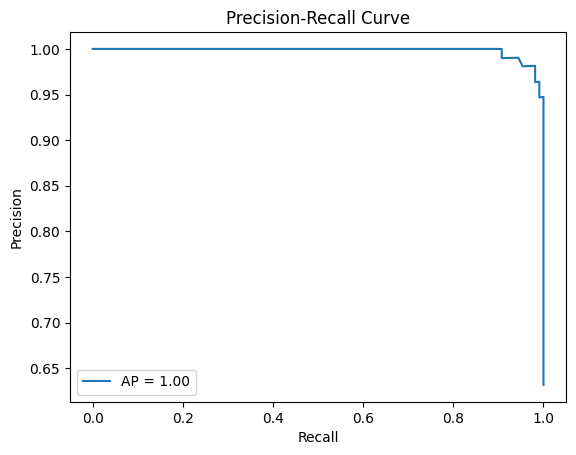

In [20]:
# 12. Random Forest Classifier + Precision-Recall (PR) Curve
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)

plt.plot(recall, precision, label=f'AP = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


In [21]:
# 13. Stacking Classifier: DecisionTree + SVM + LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

base_estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

stack_model = StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression())
stack_model.fit(X_train, y_train)
preds = stack_model.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, preds))


Stacking Accuracy: 1.0


In [22]:
# 14. Bagging Regressor: DecisionTree vs KNeighbors
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt_model = BaggingRegressor(base_estimator=DecisionTreeRegressor(), n_estimators=10, random_state=42)
knn_model = BaggingRegressor(base_estimator=KNeighborsRegressor(), n_estimators=10, random_state=42)

dt_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

print("Decision Tree Bagging MSE:", mean_squared_error(y_test, dt_model.predict(X_test)))
print("KNN Bagging MSE:", mean_squared_error(y_test, knn_model.predict(X_test)))


TypeError: BaggingRegressor.__init__() got an unexpected keyword argument 'base_estimator'

In [23]:
# 15. Bagging Classifier + Cross-Validation
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score

X, y = load_iris(return_X_y=True)
model = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42)

scores = cross_val_score(model, X, y, cv=5)
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())


TypeError: BaggingClassifier.__init__() got an unexpected keyword argument 'base_estimator'

In [24]:
# 16. Random Forest Classifier: Misclassified Samples
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)

misclassified = X_test[preds != y_test]
print(f"Number of Misclassified Samples: {len(misclassified)}")


Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Number of Misclassified Samples: 0


In [25]:
#  17. Bagging Regressor: Vary Bootstrap Samples
from sklearn.ensemble import BaggingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for b in [0.5, 0.7, 1.0]:
    model = BaggingRegressor(n_estimators=10, max_samples=b, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"Bootstrap {b} -> MSE: {mean_squared_error(y_test, preds):.4f}")


Bootstrap 0.5 -> MSE: 0.2969
Bootstrap 0.7 -> MSE: 0.2952
Bootstrap 1.0 -> MSE: 0.2862


In [26]:
# 18. Random Forest Classifier: Top 5 Features
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import numpy as np

X, y = load_breast_cancer(return_X_y=True)
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = model.feature_importances_
indices = np.argsort(importances)[-5:][::-1]
print("Top 5 Important Features:")
for idx in indices:
    print(f"{load_breast_cancer().feature_names[idx]}: {importances[idx]:.4f}")


Top 5 Important Features:
worst area: 0.1394
worst concave points: 0.1322
mean concave points: 0.1070
worst radius: 0.0828
worst perimeter: 0.0808
